# Figure Generation Log: Δ(LoB-Cq) and NfL Concentration Categorical Scatterplots

Two categorical (jittered strip) scatterplots, both built in Python/matplotlib to a Nat Comms-style
single-column spec (88 mm width, Liberation Sans — the Arial-metric-compatible substitute installed
in this environment — 6 pt base font, SVG with editable text via `svg.fonttype: none`). Okabe-Ito
colour-blind-safe palette used for all marker colours. Both use `np.random.default_rng(42)` for
jitter so layouts are reproducible.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Okabe-Ito colour-blind-safe palette (Okabe & Ito, 2008), shared by both figures
okabe_ito = {
    "orange": "#E69F00",
    "skyblue": "#56B4E9",
    "bluishgreen": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddishpurple": "#CC79A7",
    "black": "#000000",
}

plt.rcParams.update({
    "font.family": "Sans-Serif",  # Arial-metric-compatible; Arial/Helvetica not installed in this env
    "font.size": 6,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "svg.fonttype": "none",
})

## Figure 1 — Δ(LoB-Cq) by Antibody Group

### Data

- **Group 1** (n = 39 entries, 4 coded `n.d`): integer values, −6 to 4
- **Group 2** (n = 39 entries, no missing data): continuous values, 2.3 to 14.6

`n.d` entries in Group 1 are **excluded from the plot**, not coded as zero — coding non-detects as 0
would falsely pull that group toward the LoB line. **n = 35 plotted for Group 1.**


In [2]:
# --- Data ---
group_one_raw = ["-3","-1","-2","2","-3","n.d","-4","0","n.d","-6","-4","-5","-2","-2",
                  "0","-1","-2","-4","-6","-3","-4","4","-1","2","-3","0","2","0","-4",
                  "-4","0","-2","n.d","-2","0","-3","-1","n.d","-4"]

group_two = [9.0,5.6,11.2,7.2,11.1,7.7,9.6,9.9,8.8,7.1,7.1,7.0,7.0,10.8,9.7,9.5,14.6,2.3,
             9.5,10.2,9.3,12.3,9.2,7.1,7.6,7.2,12.1,7.0,7.3,7.0,7.3,7.9,10.3,7.9,10.1,6.4,
             8.9,7.6,8.5]

# Parse group one, excluding n.d (non-detected) from plotted points
group_one = [float(v) for v in group_one_raw if v != "n.d"]
n_excluded = sum(1 for v in group_one_raw if v == "n.d")

print(f"Group one: n={len(group_one)} plotted, {n_excluded} excluded (n.d)")
print(f"Group two: n={len(group_two)} plotted")

Group one: n=35 plotted, 4 excluded (n.d)
Group two: n=39 plotted


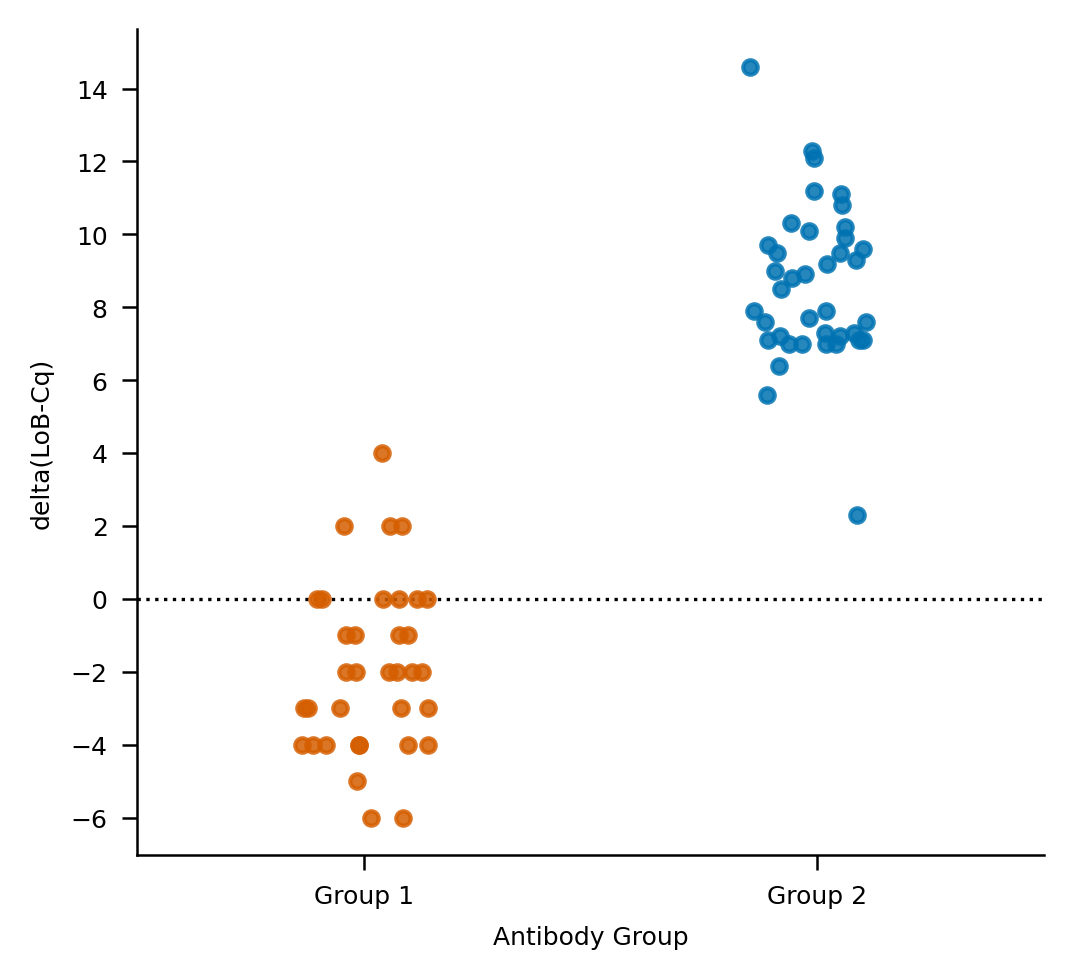

In [7]:
dot_colors = [okabe_ito["vermillion"], okabe_ito["blue"]]  # Group 1 = vermillion, Group 2 = blue

fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4), dpi=300)  # 88mm single column

rng = np.random.default_rng(42)
groups = [group_one, group_two]
labels = ["Group 1", "Group 2"]

for i, (data, color, label) in enumerate(zip(groups, dot_colors, labels)):
    x = i + 1
    jitter = rng.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(np.full(len(data), x) + jitter, data,
               s=12, color=color, alpha=0.85,
               zorder=3, label=label)

# Horizontal dotted line at y=0
ax.axhline(0, color="black", linestyle=":", linewidth=0.8, zorder=1)

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontsize=6)
ax.set_xlim(0.5, 2.5)
ax.set_xlabel("Antibody Group", fontsize=6)
ax.set_ylabel("delta(LoB-Cq)", fontsize=6)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.tick_params(axis="both", labelsize=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout(pad=0.5)
plt.savefig("categorical_scatter.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure 2 — NfL Concentration by Test Type

### Data

Three columns, almost certainly the same ~39 specimens measured across assays (rank order tracks
closely — e.g. the maximum value in each group corresponds to the same specimen):

- **Simoa NfL (4PLEX)** — n = 39, no missing data, range 1.9–1746.0 pg/mL
- **NfL-iPLA (group 1)** — n = 39 entries, 4 coded `n.d`, range 0.0–33.4 pg/mL after exclusion (n = 35 plotted)
- **NfL-iPLA (group 2)** — n = 39, no missing data, range 2.1–878.5 pg/mL

As with Figure 1, `n.d` values are excluded rather than zeroed.

In [4]:
# --- Data ---
simoa = [38.5,2.0,3.8,1.9,147.6,8.2,39.4,41.7,38.9,7.8,8.5,7.8,9.5,64.0,56.2,49.4,
         1746.0,4.6,38.4,56.2,44.4,264.4,40.3,8.5,11.5,6.2,161.6,8.1,10.1,9.4,6.8,
         7.6,96.8,9.9,64.0,4.3,44.8,9.9,53.8]

ipla1_raw = ["0.2","0.8","0.4","5.2","0.2","n.d","0.1","1.4","n.d","0.0","0.1","0.1",
             "0.6","0.3","1.8","0.9","0.4","0.1","0.0","0.2","0.1","33.4","0.9","8.6",
             "0.2","1.3","5.2","1.3","0.1","0.1","2.1","0.3","n.d","0.5","1.4","0.2",
             "0.6","n.d","0.1"]
ipla1 = [float(v) for v in ipla1_raw if v != "n.d"]
n_excluded = sum(1 for v in ipla1_raw if v == "n.d")

ipla2 = [20.09,2.113,93.419,6.124,86.497,8.701,30.201,37.332,31.25,9.08,9.03,8.75,
         8.89,65.019,54.92,43.74,878.515,4.934,28.744,47.83,24.32,179.37,23.288,8.61,
         13.21,6.19,168.045,7.59,9.5,9.88,6.682,10.859,52.828,11.03,45.436,3.908,
         22.275,9.72,17.344]

print(f"Simoa: n={len(simoa)}")
print(f"iPLA group1: n={len(ipla1)} plotted, {n_excluded} excluded (n.d)")
print(f"iPLA group2: n={len(ipla2)}")

Simoa: n=39
iPLA group1: n=35 plotted, 4 excluded (n.d)
iPLA group2: n=39


OK: no data points fall inside the break gap (330, 330).


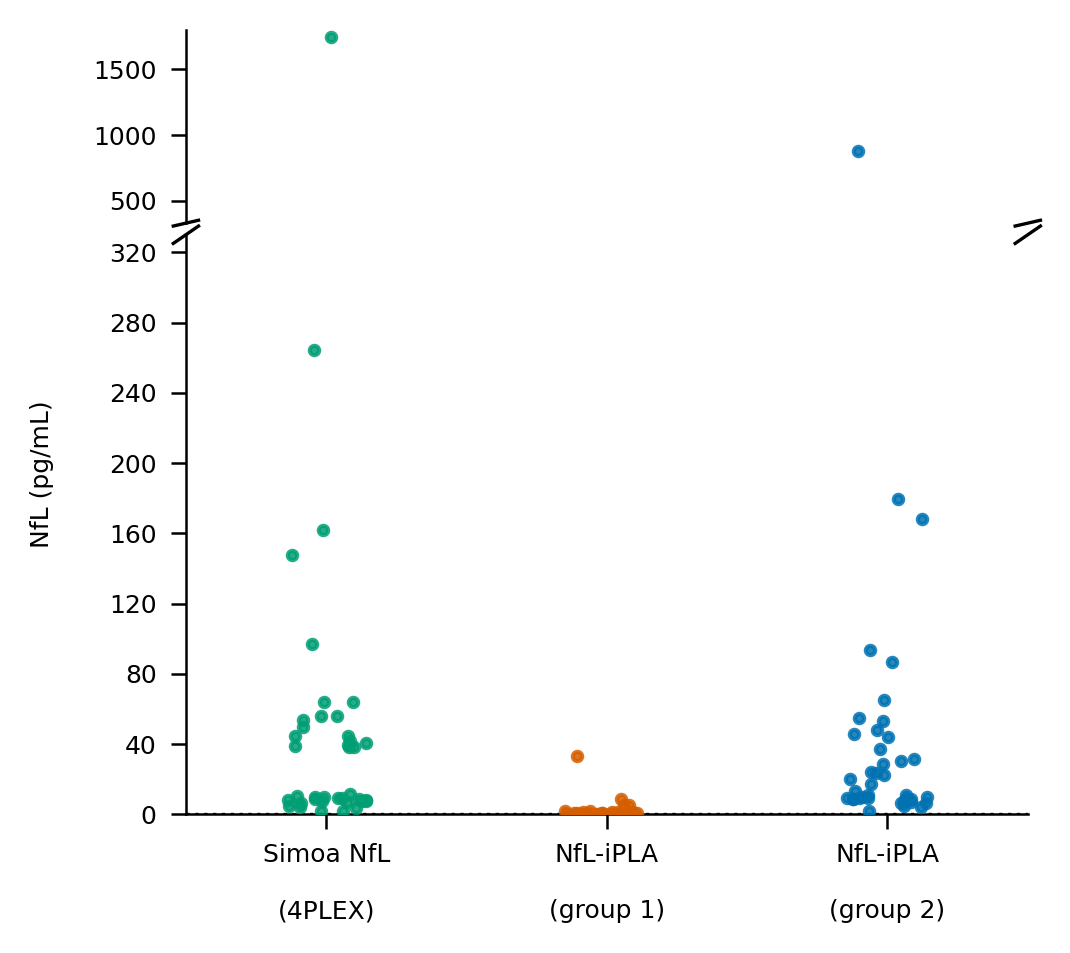

In [13]:
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

# Simoa NfL, NfL-iPLA group1, NfL-iPLA group2
dot_colors = [okabe_ito["bluishgreen"], okabe_ito["vermillion"], okabe_ito["blue"]]
groups = [simoa, ipla1, ipla2]
labels = ["Simoa NfL\n\n(4PLEX)", "NfL-iPLA\n\n(group 1)", "NfL-iPLA\n\n(group 2)"]

# =====================================================================
# BREAK PARAMETERS -- edit these to change where/how the axis breaks.
# Ticks below are derived from these automatically, so changing a limit
# can never leave a stale tick outside the visible range (the earlier
# version of this cell had that bug: changing BOTTOM_MAX without also
# updating the bottom panel's tick list left ticks sitting above the
# new ylim, where matplotlib silently drops them).
# =====================================================================
BOTTOM_MIN   = 0      # bottom panel y-axis starts here
BOTTOM_MAX   = 330    # bottom panel y-axis ends here (top of the break)
TOP_MIN      = 330   # top panel y-axis starts here (bottom of the break)
TOP_MAX      = 1800   # top panel y-axis ends here
HEIGHT_RATIO = [1, 3]   # [top, bottom] relative panel heights
BOTTOM_TICK_STEP = 40      # tick spacing within the bottom panel
TOP_N_TICKS      = 4       # roughly how many ticks to aim for in the top panel
# =====================================================================

# --- Manual broken axis: two stacked subplots sharing x, no third-party dependency ---
fig = plt.figure(figsize=(88/25.4, 80/25.4), dpi=300)
gs = gridspec.GridSpec(2, 1, height_ratios=HEIGHT_RATIO, hspace=0.03)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

ax_top.set_ylim(TOP_MIN, TOP_MAX)
ax_bot.set_ylim(BOTTOM_MIN, BOTTOM_MAX)

rng = np.random.default_rng(42)
for i, (data, color, label) in enumerate(zip(groups, dot_colors, labels)):
    x = i + 1
    jitter = rng.uniform(-0.15, 0.15, size=len(data))
    xs = np.full(len(data), x) + jitter
    ax_top.scatter(xs, data, s=5, color=color, alpha=0.85, zorder=3)
    ax_bot.scatter(xs, data, s=5, color=color, alpha=0.85, zorder=3)

# Zero line only makes sense in the bottom panel
ax_bot.axhline(0, color="black", linestyle=":", linewidth=0.8, zorder=1)

# Ticks are DERIVED from the panel limits above, so they track BOTTOM_MAX /
# TOP_MIN / TOP_MAX automatically -- no more stale tick lists.
ax_bot.yaxis.set_major_locator(mticker.MultipleLocator(BOTTOM_TICK_STEP))
ax_top.yaxis.set_major_locator(mticker.MaxNLocator(nbins=TOP_N_TICKS, steps=[1, 2, 5, 10]))

for ax in (ax_top, ax_bot):
    ax.set_xlim(0.5, 3.5)
    ax.set_xticks([1, 2, 3])
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=6)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.6)

# Hide the shared spine between panels -- this is what creates the "break" look
ax_top.spines["bottom"].set_visible(False)
ax_top.tick_params(labelbottom=False, bottom=False)
ax_top.spines["top"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_bot.set_xticklabels(labels, fontsize=6)

# Diagonal break marks ("//") drawn manually at the seam between panels,
# in axes-fraction coordinates so they sit correctly regardless of figure size
d = 0.015
kwargs = dict(transform=ax_top.transAxes, color="black", clip_on=False, linewidth=0.8)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

fig.subplots_adjust(left=0.16, bottom=0.14, right=0.97, top=0.97)
# fig.supxlabel("\n\nTest Type", fontsize=6, y=0.001)
fig.supylabel("NfL (pg/mL)", fontsize=6, x=0.01)

# Sanity check: warn if any data point falls inside the break gap (invisible)
all_vals = [v for g in groups for v in g]
in_gap = [v for v in all_vals if BOTTOM_MAX < v < TOP_MIN]
if in_gap:
    print(f"WARNING: {len(in_gap)} point(s) fall inside the break gap and will not be visible: {in_gap}")
else:
    print(f"OK: no data points fall inside the break gap ({BOTTOM_MAX}, {TOP_MIN}).")

plt.savefig("categorical_scatter_nfl.svg", format="svg", bbox_inches="tight")
plt.show()

## Open items flagged during generation (not yet resolved)

1. **Figure 1:** Group 1 and Group 2 occupy non-overlapping numeric ranges (−6 to 4 vs. 2.3 to 14.6).
   If both represent the same Δ(LoB-Cq) metric for two antibody candidates, this is a near-total
   separation between groups — worth confirming this isn't a units/calculation discrepancy before it
   goes into a manuscript figure.
2. **Figure 2:** NfL-iPLA group 1 sits almost entirely below 10 pg/mL (33 of 35 plotted points),
   roughly 5–10x lower than both Simoa and NfL-iPLA group 2 across the same specimen set. This looks
   like a systematic calibration or scale difference between the "group 1" and "group 2" NfL-iPLA
   datasets, not assay noise — relevant to the commutability/calibrator concerns already in scope for
   the manuscript.

## Files produced

- `categorical_scatter.svg` / `.png` — Figure 1
- `categorical_scatter_nfl.svg` / `.png` — Figure 2